# Matrix Inversion Toolkit for Quants
### Inverses · Schur complements · Sherman–Morrison–Woodbury · the determinant lemma · and the conditional Gaussian

Welcome! This notebook builds a small **toolbox of matrix-algebra identities** and then uses them to crack one of the
most-asked results in quant interviews: the **conditional distribution of a multivariate normal**.

Think of it like learning a few keyboard shortcuts. Each identity on its own looks like an obscure trick, but together
they let you manipulate large covariance matrices *without ever crunching a giant inverse*. That is exactly what you need
when a portfolio has thousands of assets, or when an interviewer asks "given that these 3 stocks moved, what do you expect
the other 2 to do?"

> **Why a quant should care.** Almost everything linear-Gaussian — OLS, ridge regression, the Kalman filter, Gaussian
> processes, factor models, pairs trading — is secretly *one of these identities applied to a covariance matrix*. Master
> the toolbox once and a dozen interview questions collapse into the same move.

**Roadmap**

1. The inverse of a square matrix — what it really *means*
2. Block matrices & the **Schur complement** (the star of the show)
3. The **matrix inversion lemma** (Sherman–Morrison–Woodbury)
4. The **matrix determinant lemma**
5. A 2-minute refresher on the multivariate normal
6. Deriving the **conditional Gaussian** with Schur complements
7. Visualizing conditioning + an interactive slider
8. Summary table

Every identity is verified numerically with NumPy, so you can *trust but verify*.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, det, slogdet

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]

def close(a, b, tol=1e-9):
    # Pretty-print whether two arrays match — our 'trust but verify' helper.
    a, b = np.atleast_1d(a), np.atleast_1d(b)
    err = np.max(np.abs(a - b))
    print(f"max abs difference = {err:.2e}   ->   {'MATCH ✅' if err < tol else 'MISMATCH ❌'}")
    return err < tol

print("Setup ready.")

Setup ready.


---
## 1 · The inverse of a square matrix

### What it *means* before what it *is*

A square matrix $\mathbf{A}$ is a **linear transformation**: feed it a vector, it stretches/rotates/shears it into a new
vector. The **inverse** $\mathbf{A}^{-1}$ is simply the transformation that **undoes** that — like pressing Ctrl-Z.

$$\mathbf{A}\,\mathbf{A}^{-1} = \mathbf{A}^{-1}\mathbf{A} = \mathbf{I}$$

where $\mathbf{I}$ is the identity ("do nothing") matrix. So $\mathbf{A}^{-1}$ is the unique matrix that, applied after
$\mathbf{A}$, brings every vector back home.

| Symbol | Meaning |
|---|---|
| $\mathbf{A}$ | an $n\times n$ square matrix (a transformation) |
| $\mathbf{I}$ | identity matrix — the "do nothing" transform |
| $\mathbf{A}^{-1}$ | the undo transform |
| $\det(\mathbf{A})$ | the volume-scaling factor of $\mathbf{A}$ |

### When does the undo exist?

You can only undo a transformation if it didn't **destroy information**. If $\mathbf{A}$ squashes 3D space onto a flat
plane, you can never recover the lost dimension — there is no inverse. The number that detects this collapse is the
**determinant**:

$$\det(\mathbf{A}) = 0 \iff \mathbf{A}\text{ is singular (no inverse)}.$$

The determinant is literally the factor by which $\mathbf{A}$ scales volume. A determinant of $0$ means volume got
crushed to nothing — information lost.

### The 2×2 formula everyone should memorize

$$\mathbf{A} = \begin{pmatrix} a & b \\ c & d \end{pmatrix}
\quad\Longrightarrow\quad
\mathbf{A}^{-1} = \frac{1}{ad - bc}\begin{pmatrix} d & -b \\ -c & a \end{pmatrix}.$$

Notice $ad-bc$ is exactly $\det(\mathbf{A})$ sitting in the denominator — if it's zero, the formula blows up, confirming
no inverse exists.

> **Key insight:** "Invertible" = "reversible" = "no information lost" = "non-zero determinant". These are four ways of
> saying the same thing. Interviewers love checking you can switch between them fluidly.

> **Quant interview flag 🚩** Expect the 2×2 inverse and "*when is a matrix invertible?*" as warm-up questions. The
> crisp answer: invertible $\iff$ $\det \neq 0$ $\iff$ full rank $\iff$ columns linearly independent $\iff$ the only
> solution to $\mathbf{A}\mathbf{x}=\mathbf{0}$ is $\mathbf{x}=\mathbf{0}$.


In [2]:
# Verify the 2x2 formula from scratch against numpy
a, b, c, d = 4.0, 7.0, 2.0, 6.0
A = np.array([[a, b],
              [c, d]])

det_A = a*d - b*c
A_inv_manual = (1/det_A) * np.array([[ d, -b],
                                     [-c,  a]])

print("manual det =", det_A, " numpy det =", det(A))
print("\nmanual inverse:\n", A_inv_manual)
print("\nnumpy inverse:\n", inv(A))
print("\nA @ A_inv (should be identity):\n", np.round(A @ A_inv_manual, 12))
print()
close(A_inv_manual, inv(A))

manual det = 10.0  numpy det = 10.000000000000002

manual inverse:
 [[ 0.6 -0.7]
 [-0.2  0.4]]

numpy inverse:
 [[ 0.6 -0.7]
 [-0.2  0.4]]

A @ A_inv (should be identity):
 [[ 1. -0.]
 [ 0.  1.]]

max abs difference = 0.00e+00   ->   MATCH ✅


np.True_

Let's *see* what an inverse does. We apply $\mathbf{A}$ to the unit grid (deforming it), then apply
$\mathbf{A}^{-1}$ to snap it back to the original.

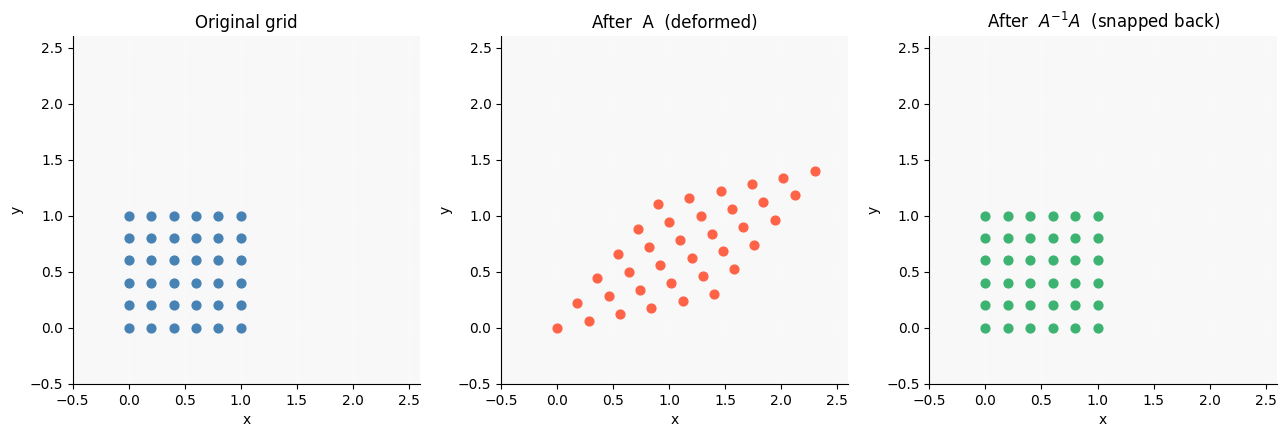

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# build a little unit square of points
g = np.linspace(0, 1, 6)
xx, yy = np.meshgrid(g, g)
pts = np.vstack([xx.ravel(), yy.ravel()])          # 2 x N

M = np.array([[1.4, 0.9],
              [0.3, 1.1]])                           # some transformation

stages = [pts, M @ pts, inv(M) @ (M @ pts)]
titles = ["Original grid", "After  A  (deformed)", "After  $A^{-1}A$  (snapped back)"]
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax, P, t, col in zip(axes, stages, titles, colors):
    ax.scatter(P[0], P[1], c=col, s=40, zorder=3)
    ax.set_title(t)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-0.5, 2.6); ax.set_ylim(-0.5, 2.6)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 2 · Block matrices & the Schur complement

### Why blocks?

Real covariance matrices are huge, but they are often naturally split into **groups** — e.g. "tech stocks" vs "energy
stocks", or "variables I observed" vs "variables I want to predict". We write the matrix in **block form**:

$$\mathbf{M} = \begin{pmatrix} \mathbf{A} & \mathbf{B} \\ \mathbf{C} & \mathbf{D} \end{pmatrix}$$

where $\mathbf{A}$ and $\mathbf{D}$ are square (the within-group parts) and $\mathbf{B}, \mathbf{C}$ are the cross-group
couplings.

### The big idea: block Gaussian elimination

You already know how to solve a 2-variable system by eliminating one variable. The **Schur complement** is exactly that
move, done on *blocks* instead of scalars. We use $\mathbf{A}$ to eliminate $\mathbf{C}$:

$$\boxed{\;\mathbf{M}/\mathbf{A} \;\equiv\; \mathbf{D} - \mathbf{C}\,\mathbf{A}^{-1}\mathbf{B}\;}$$

This is read "**the Schur complement of $\mathbf{A}$ in $\mathbf{M}$**". Intuitively it is **"$\mathbf{D}$, after we
subtract off everything that block $\mathbf{D}$ could already explain through block $\mathbf{A}$."** It's the *leftover*
$\mathbf{D}$ once the influence routed through $\mathbf{A}$ is removed.

### The factorization that makes everything work

$\mathbf{M}$ factors into a lower-triangular × block-diagonal × upper-triangular sandwich (this is just block LU):

$$\mathbf{M} =
\begin{pmatrix} \mathbf{I} & \mathbf{0} \\ \mathbf{C}\mathbf{A}^{-1} & \mathbf{I} \end{pmatrix}
\begin{pmatrix} \mathbf{A} & \mathbf{0} \\ \mathbf{0} & \mathbf{M}/\mathbf{A} \end{pmatrix}
\begin{pmatrix} \mathbf{I} & \mathbf{A}^{-1}\mathbf{B} \\ \mathbf{0} & \mathbf{I} \end{pmatrix}$$

The two triangular matrices have determinant $1$ (their diagonals are all $1$). Inverting a product reverses it and
inverts each piece, and the triangular pieces invert by just flipping the sign of the off-diagonal block. That gives the
two payoffs below.

### Payoff 1 — block determinant

Because $\det$ of a product is the product of $\det$s, and the triangular factors contribute $1$:

$$\boxed{\;\det(\mathbf{M}) = \det(\mathbf{A})\,\det(\mathbf{M}/\mathbf{A})\;}$$

A scary $n\times n$ determinant becomes two smaller ones. (Compare: for scalars $\det\begin{psmallmatrix}a&b\\c&d\end{psmallmatrix}=a(d-c a^{-1} b)=ad-bc$. Same thing!)

### Payoff 2 — block inverse

Inverting the sandwich gives a closed form for $\mathbf{M}^{-1}$. Writing $\mathbf{S} = \mathbf{M}/\mathbf{A} =
\mathbf{D}-\mathbf{C}\mathbf{A}^{-1}\mathbf{B}$:

$$\mathbf{M}^{-1} =
\begin{pmatrix}
\mathbf{A}^{-1} + \mathbf{A}^{-1}\mathbf{B}\,\mathbf{S}^{-1}\mathbf{C}\mathbf{A}^{-1} & -\mathbf{A}^{-1}\mathbf{B}\,\mathbf{S}^{-1} \\
-\mathbf{S}^{-1}\mathbf{C}\mathbf{A}^{-1} & \mathbf{S}^{-1}
\end{pmatrix}$$

Don't memorize every entry — memorize the **pattern**: the bottom-right block of the inverse is just $\mathbf{S}^{-1}$,
the inverse of the Schur complement. That single fact is what produces the conditional-Gaussian covariance later.

> **Key insight:** The Schur complement $\mathbf{D}-\mathbf{C}\mathbf{A}^{-1}\mathbf{B}$ is "block $\mathbf{D}$ with the
> part already explained by $\mathbf{A}$ removed." Remember it as **subtracting what the other block already accounts
> for** — that single sentence reappears as the conditional variance of a Gaussian.

> **Quant interview flag 🚩** Schur complements are *the* unlock for the conditional-Gaussian derivation and show up in
> Kalman filters and least-squares. If you can write the block-inverse pattern from memory you're ahead of most
> candidates.


In [4]:
# Verify the block determinant and block inverse identities
n1, n2 = 3, 2
# build a random invertible M, split into blocks
M = rng.normal(size=(n1+n2, n1+n2))
M = M + (n1+n2)*np.eye(n1+n2)        # make it well-conditioned

A = M[:n1, :n1]; B = M[:n1, n1:]
C = M[n1:, :n1]; D = M[n1:, n1:]

S = D - C @ inv(A) @ B               # Schur complement M/A

print("Block determinant identity:")
close(det(M), det(A) * det(S))

# Reassemble M^{-1} from blocks
Ai = inv(A); Si = inv(S)
top_left  = Ai + Ai @ B @ Si @ C @ Ai
top_right = -Ai @ B @ Si
bot_left  = -Si @ C @ Ai
bot_right = Si
M_inv_block = np.block([[top_left, top_right],
                        [bot_left, bot_right]])

print("\nBlock inverse identity:")
close(M_inv_block, inv(M))

Block determinant identity:
max abs difference = 0.00e+00   ->   MATCH ✅

Block inverse identity:
max abs difference = 2.78e-17   ->   MATCH ✅


np.True_

---
## 3 · The matrix inversion lemma (Sherman–Morrison–Woodbury)

### The problem it solves

Suppose you already know $\mathbf{A}^{-1}$ (maybe $\mathbf{A}$ is diagonal and trivial to invert). Now someone *perturbs*
$\mathbf{A}$ by a **low-rank update** — they add a thin correction $\mathbf{U}\mathbf{C}\mathbf{V}^\top$:

$$\big(\mathbf{A} + \mathbf{U}\mathbf{C}\mathbf{V}^\top\big)^{-1} = \;?$$

Recomputing a full $n\times n$ inverse from scratch costs $O(n^3)$. But if the update has small rank $k$, the **Woodbury
identity** lets you patch your existing inverse for only $O(k^3)$ extra work:

$$\boxed{\;\big(\mathbf{A} + \mathbf{U}\mathbf{C}\mathbf{V}^\top\big)^{-1}
= \mathbf{A}^{-1} - \mathbf{A}^{-1}\mathbf{U}\big(\mathbf{C}^{-1} + \mathbf{V}^\top\mathbf{A}^{-1}\mathbf{U}\big)^{-1}\mathbf{V}^\top\mathbf{A}^{-1}\;}$$

| Symbol | Shape | Role |
|---|---|---|
| $\mathbf{A}$ | $n\times n$ | big matrix you already inverted |
| $\mathbf{U},\mathbf{V}$ | $n\times k$ | thin "directions" of the update |
| $\mathbf{C}$ | $k\times k$ | small core ($k \ll n$) |

The only new inverse you compute is the **small** $k\times k$ matrix in the middle. Everything else reuses
$\mathbf{A}^{-1}$.

### Where does it come from?

It is *literally* the Schur-complement block inverse from Section 2 applied to the augmented matrix
$\begin{psmallmatrix}\mathbf{A}&-\mathbf{U}\\\mathbf{V}^\top&\mathbf{C}^{-1}\end{psmallmatrix}$ — computing its
inverse two ways (eliminate $\mathbf{A}$ first vs. eliminate the corner first) and matching the top-left blocks. So
Woodbury is not a new idea, it's the Schur complement wearing a different hat.

### The rank-1 special case: Sherman–Morrison

When the update is a single outer product ($\mathbf{u}\mathbf{v}^\top$, rank 1), it simplifies to something you can
apply by hand:

$$\big(\mathbf{A} + \mathbf{u}\mathbf{v}^\top\big)^{-1}
= \mathbf{A}^{-1} - \frac{\mathbf{A}^{-1}\mathbf{u}\,\mathbf{v}^\top\mathbf{A}^{-1}}{1 + \mathbf{v}^\top\mathbf{A}^{-1}\mathbf{u}}.$$

The denominator is just a **scalar** — no matrix inversion at all! This is the workhorse behind online/recursive least
squares, where each new data point is a rank-1 update to the inverse covariance.

> **Key insight:** Woodbury turns "*invert a big perturbed matrix*" into "*invert a tiny $k\times k$ matrix*." Whenever
> you see a cheap base matrix plus a low-rank bump, this identity is the move.

> **Quant interview flag 🚩** Sherman–Morrison is a classic. Typical prompt: "you have $\Sigma^{-1}$ and one new asset /
> one new observation arrives — update the inverse efficiently." The answer is rank-1 Woodbury, $O(n^2)$ not $O(n^3)$.


In [5]:
# Verify Woodbury (general low-rank) and Sherman-Morrison (rank 1)
n, k = 6, 2
A = rng.normal(size=(n, n)); A = A @ A.T + n*np.eye(n)   # SPD, easy to trust
U = rng.normal(size=(n, k))
V = rng.normal(size=(n, k))
Cc = rng.normal(size=(k, k)); Cc = Cc @ Cc.T + k*np.eye(k)

lhs = inv(A + U @ Cc @ V.T)
Ai = inv(A)
rhs = Ai - Ai @ U @ inv(inv(Cc) + V.T @ Ai @ U) @ V.T @ Ai
print("Woodbury identity:")
close(lhs, rhs)

# Sherman-Morrison rank-1
u = rng.normal(size=(n, 1)); v = rng.normal(size=(n, 1))
lhs1 = inv(A + u @ v.T)
rhs1 = Ai - (Ai @ u @ v.T @ Ai) / (1 + (v.T @ Ai @ u))
print("\nSherman-Morrison (rank-1):")
close(lhs1, rhs1)

Woodbury identity:
max abs difference = 8.33e-17   ->   MATCH ✅

Sherman-Morrison (rank-1):
max abs difference = 2.78e-17   ->   MATCH ✅


np.True_

Low-rank updates are not just elegant — they are **fast**. Let's time the naive full re-inversion against the
Sherman–Morrison patch as the matrix grows.

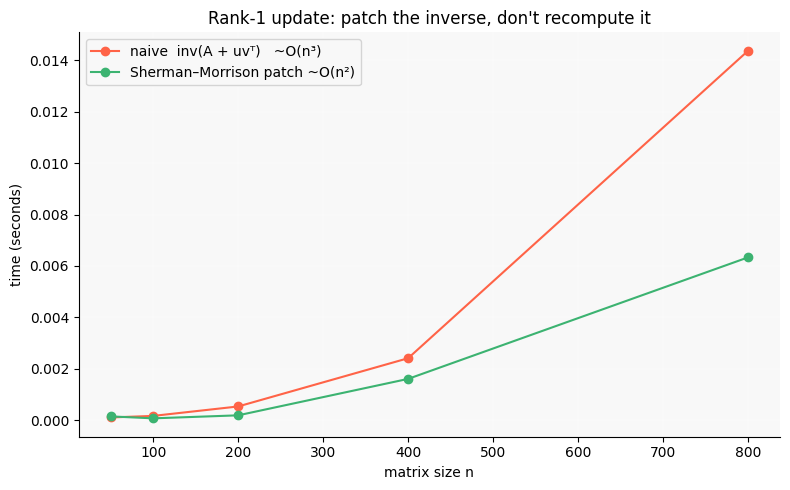

speed-up at n = 800 : 2.3 x faster


In [6]:
import time

sizes = [50, 100, 200, 400, 800]
naive_t, sm_t = [], []

for n in sizes:
    A = rng.normal(size=(n, n)); A = A @ A.T + n*np.eye(n)
    Ai = inv(A)                               # assume we already have this
    u = rng.normal(size=(n, 1)); v = rng.normal(size=(n, 1))

    t0 = time.perf_counter()
    _ = inv(A + u @ v.T)                       # naive: full re-inversion
    naive_t.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    _ = Ai - (Ai @ u @ v.T @ Ai) / (1 + (v.T @ Ai @ u))   # rank-1 patch
    sm_t.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, naive_t, "o-", color=PALETTE[1], label="naive  inv(A + uvᵀ)   ~O(n³)")
ax.plot(sizes, sm_t,    "o-", color=PALETTE[2], label="Sherman–Morrison patch ~O(n²)")
ax.set_xlabel("matrix size n"); ax.set_ylabel("time (seconds)")
ax.set_title("Rank-1 update: patch the inverse, don't recompute it")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("speed-up at n =", sizes[-1], ":", round(naive_t[-1]/sm_t[-1], 1), "x faster")

---
## 4 · The matrix determinant lemma

The same low-rank-update idea applies to **determinants**. If you know $\det(\mathbf{A})$ and add a low-rank bump, the new
determinant is the old one times a small correction:

$$\boxed{\;\det\!\big(\mathbf{A} + \mathbf{U}\mathbf{C}\mathbf{V}^\top\big)
= \det(\mathbf{A})\;\det(\mathbf{C})\;\det\!\big(\mathbf{C}^{-1} + \mathbf{V}^\top\mathbf{A}^{-1}\mathbf{U}\big)\;}$$

and the **rank-1** version is wonderfully simple:

$$\det\!\big(\mathbf{A} + \mathbf{u}\mathbf{v}^\top\big) = \det(\mathbf{A})\,\big(1 + \mathbf{v}^\top\mathbf{A}^{-1}\mathbf{u}\big).$$

That trailing factor $\big(1 + \mathbf{v}^\top\mathbf{A}^{-1}\mathbf{u}\big)$ is the **exact same scalar** that appeared in
the Sherman–Morrison denominator — no coincidence, both fall out of the Schur identity $\det\mathbf{M} = \det\mathbf{A}\,
\det(\mathbf{M}/\mathbf{A})$ applied to the augmented matrix.

> **Why it matters for quants.** The multivariate-normal density has a $\det(\mathbf{\Sigma})$ in its normalizing
> constant. When you update a model with new data (a low-rank change to $\mathbf{\Sigma}$), this lemma updates the
> log-likelihood cheaply instead of recomputing a full determinant — central to Gaussian-process and Kalman likelihoods.


In [7]:
# Verify the matrix determinant lemma (general + rank-1)
n, k = 6, 2
A = rng.normal(size=(n, n)); A = A @ A.T + n*np.eye(n)
U = rng.normal(size=(n, k)); V = rng.normal(size=(n, k))
Cc = rng.normal(size=(k, k)); Cc = Cc @ Cc.T + k*np.eye(k)

lhs = det(A + U @ Cc @ V.T)
rhs = det(A) * det(Cc) * det(inv(Cc) + V.T @ inv(A) @ U)
print("Matrix determinant lemma (general):")
close(lhs, rhs)

u = rng.normal(size=(n, 1)); v = rng.normal(size=(n, 1))
lhs1 = det(A + u @ v.T)
rhs1 = det(A) * (1 + (v.T @ inv(A) @ u).item())
print("\nRank-1 determinant lemma:")
close(lhs1, rhs1)
print("\nNotice: the (1 + vᵀA⁻¹u) factor is the SAME scalar as Sherman–Morrison's denominator.")

Matrix determinant lemma (general):
max abs difference = 3.49e-10   ->   MATCH ✅

Rank-1 determinant lemma:
max abs difference = 2.33e-10   ->   MATCH ✅

Notice: the (1 + vᵀA⁻¹u) factor is the SAME scalar as Sherman–Morrison's denominator.


---
## 5 · A 2-minute refresher on the multivariate normal

A vector $\mathbf{x}\in\mathbb{R}^n$ is **multivariate normal**, written $\mathbf{x}\sim\mathcal{N}(\boldsymbol\mu,
\mathbf{\Sigma})$, if its density is

$$p(\mathbf{x}) = \frac{1}{(2\pi)^{n/2}\,\det(\mathbf{\Sigma})^{1/2}}
\exp\!\Big(-\tfrac12 (\mathbf{x}-\boldsymbol\mu)^\top \mathbf{\Sigma}^{-1}(\mathbf{x}-\boldsymbol\mu)\Big).$$

| Symbol | Meaning (intuition) |
|---|---|
| $\boldsymbol\mu$ | the center of the cloud (where it's most likely) |
| $\mathbf{\Sigma}$ | covariance — the **shape & tilt** of the elliptical cloud |
| $\mathbf{\Sigma}^{-1}$ | "precision" — appears in the exponent, controls how fast probability falls off |
| $\det(\mathbf{\Sigma})$ | overall "volume" of the cloud — the normalizer |

The contours of constant density are **ellipses** (ellipsoids in higher dim). The covariance entries tell you the spread
along each axis ($\Sigma_{ii}$) and how the variables lean on each other ($\Sigma_{ij}$).

Now split the vector into two groups, the ones we will **observe** ($\mathbf{x}_2$) and the ones we want to **predict**
($\mathbf{x}_1$):

$$\mathbf{x} = \begin{pmatrix}\mathbf{x}_1\\\mathbf{x}_2\end{pmatrix},\quad
\boldsymbol\mu = \begin{pmatrix}\boldsymbol\mu_1\\\boldsymbol\mu_2\end{pmatrix},\quad
\mathbf{\Sigma} = \begin{pmatrix}\mathbf{\Sigma}_{11} & \mathbf{\Sigma}_{12}\\ \mathbf{\Sigma}_{21} & \mathbf{\Sigma}_{22}\end{pmatrix}.$$

This is the block structure from Section 2 — and that is the whole reason we built the toolbox.


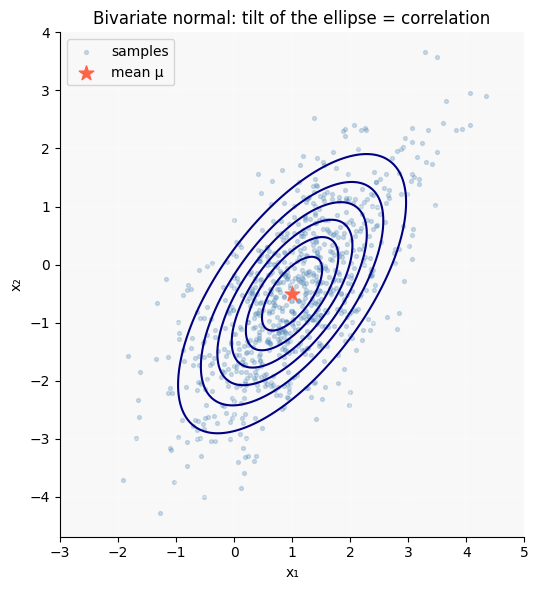

Correlation between x₁ and x₂: 0.653


In [8]:
# Build a 2D Gaussian and draw its elliptical contours + samples
mu = np.array([1.0, -0.5])
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.5]])

# sample
X = rng.multivariate_normal(mu, Sigma, size=800)

# density on a grid
gx = np.linspace(-3, 5, 200); gy = np.linspace(-4, 4, 200)
GX, GY = np.meshgrid(gx, gy)
pos = np.dstack([GX, GY])
Si = inv(Sigma); norm = 1/(2*np.pi*np.sqrt(det(Sigma)))
diff = pos - mu
expo = -0.5*np.einsum('...i,ij,...j->...', diff, Si, diff)
Z = norm*np.exp(expo)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:,0], X[:,1], s=8, alpha=0.25, color=PALETTE[0], label="samples")
cs = ax.contour(GX, GY, Z, levels=6, colors=PALETTE[4], linewidths=1.5)
ax.scatter(*mu, color=PALETTE[1], s=120, marker="*", zorder=5, label="mean μ")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.set_title("Bivariate normal: tilt of the ellipse = correlation")
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect("equal"); plt.tight_layout(); plt.show()
print("Correlation between x₁ and x₂:", round(Sigma[0,1]/np.sqrt(Sigma[0,0]*Sigma[1,1]), 3))

---
## 6 · The headline result: the conditional Gaussian

**The question.** We observe $\mathbf{x}_2 = \mathbf{a}$ (say, "energy stocks moved by this much"). What is our updated
belief about $\mathbf{x}_1$? In symbols, what is $p(\mathbf{x}_1 \mid \mathbf{x}_2 = \mathbf{a})$?

**The answer** (the formula every quant should be able to produce on a whiteboard):

$$\mathbf{x}_1 \mid \mathbf{x}_2=\mathbf{a} \;\sim\; \mathcal{N}\big(\boldsymbol\mu_{1\mid 2},\,\mathbf{\Sigma}_{1\mid 2}\big)$$

$$\boxed{\;\boldsymbol\mu_{1\mid 2} = \boldsymbol\mu_1 + \mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}(\mathbf{a}-\boldsymbol\mu_2)\;}$$
$$\boxed{\;\mathbf{\Sigma}_{1\mid 2} = \mathbf{\Sigma}_{11} - \mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}\mathbf{\Sigma}_{21}\;}$$

Look closely: **the conditional covariance is exactly the Schur complement** $\mathbf{\Sigma}/\mathbf{\Sigma}_{22}$! All
that machinery was building to this.

### Reading the formulas like a human

- **Conditional mean.** Start at the prior mean $\boldsymbol\mu_1$, then *adjust* by how surprising the observation was,
  $(\mathbf{a}-\boldsymbol\mu_2)$, scaled by $\mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}$ — the **regression
  coefficient** of $\mathbf{x}_1$ on $\mathbf{x}_2$. (Yes: this *is* linear regression / "beta" in disguise.)
- **Conditional covariance.** Start with the prior spread $\mathbf{\Sigma}_{11}$ and **subtract** the variance that
  $\mathbf{x}_2$ explained, $\mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}\mathbf{\Sigma}_{21}$. Observing always
  *reduces* uncertainty (the subtracted term is positive semidefinite). And notice it does **not** depend on the value
  $\mathbf{a}$ — for a Gaussian, *how much* you learn doesn't depend on *what* you saw.

### The derivation (Schur complement in action)

We want the exponent of the joint density, $-\tfrac12 (\mathbf{x}-\boldsymbol\mu)^\top\mathbf{\Sigma}^{-1}(\mathbf{x}-
\boldsymbol\mu)$, and we want to **isolate the part involving $\mathbf{x}_1$**. The trick is to express
$\mathbf{\Sigma}^{-1}$ in blocks. From the Schur block-inverse (Section 2), with $\mathbf{S} = \mathbf{\Sigma}_{11} -
\mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}\mathbf{\Sigma}_{21}$ (Schur complement of $\mathbf{\Sigma}_{22}$):

$$\mathbf{\Sigma}^{-1} =
\begin{pmatrix}
\mathbf{S}^{-1} & -\mathbf{S}^{-1}\mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}\\
-\mathbf{\Sigma}_{22}^{-1}\mathbf{\Sigma}_{21}\mathbf{S}^{-1} & \;\;\bullet
\end{pmatrix}.$$

Plugging this into the quadratic form and collecting the terms in $\mathbf{x}_1$, the exponent becomes (up to constants in
$\mathbf{x}_1$)

$$-\tfrac12\Big(\mathbf{x}_1 - \boldsymbol\mu_1 - \mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}(\mathbf{x}_2-\boldsymbol\mu_2)\Big)^\top
\mathbf{S}^{-1}
\Big(\mathbf{x}_1 - \boldsymbol\mu_1 - \mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}(\mathbf{x}_2-\boldsymbol\mu_2)\Big).$$

This is the exponent of a Gaussian in $\mathbf{x}_1$ with **mean** $\boldsymbol\mu_1 + \mathbf{\Sigma}_{12}
\mathbf{\Sigma}_{22}^{-1}(\mathbf{x}_2-\boldsymbol\mu_2)$ and **covariance** $\mathbf{S}$ — exactly the boxed formulas.
"Completing the square" with blocks *is* the Schur complement.

> **Key insight:** Conditioning a Gaussian = **block Gaussian elimination on its covariance**. The conditional
> covariance is the Schur complement; the conditional mean is a linear regression. One identity, two famous formulas.

> **Quant interview flag 🚩 (high frequency!)** "Derive / state the conditional distribution of a multivariate normal" is
> one of the most common quant interview questions. At minimum, memorize the two boxed formulas and be able to say *the
> conditional covariance is the Schur complement and the mean is the regression of $x_1$ on $x_2$*. Bonus points for
> noting it doesn't depend on the observed value.


In [9]:
# Verify the conditional-Gaussian formulas by Monte Carlo.
# Full 3D Gaussian; condition x1 (first 1 var) on x2 (last 2 vars).
d1, d2 = 1, 2
mu = np.array([0.5, -1.0, 2.0])
L = rng.normal(size=(3,3)); Sigma = L @ L.T + np.eye(3)   # SPD covariance

mu1, mu2 = mu[:d1], mu[d1:]
S11 = Sigma[:d1, :d1]; S12 = Sigma[:d1, d1:]
S21 = Sigma[d1:, :d1]; S22 = Sigma[d1:, d1:]

# choose an observed value a for x2
a = np.array([0.0, 3.0])

# analytic conditional
mu_cond = mu1 + S12 @ inv(S22) @ (a - mu2)
Sig_cond = S11 - S12 @ inv(S22) @ S21
print("Analytic conditional mean      :", np.round(mu_cond, 4))
print("Analytic conditional covariance:", np.round(Sig_cond, 4))

# Monte Carlo check: sample the joint, keep samples whose x2 is near a
X = rng.multivariate_normal(mu, Sigma, size=2_000_000)
mask = np.all(np.abs(X[:, d1:] - a) < 0.15, axis=1)
x1_given = X[mask, :d1]
print(f"\nMonte Carlo ({mask.sum()} accepted samples near x2 = a):")
print("empirical conditional mean      :", np.round(x1_given.mean(0), 4))
print("empirical conditional variance  :", np.round(x1_given.var(0), 4))
print()
close(mu_cond, x1_given.mean(0), tol=5e-2)
close(Sig_cond.ravel(), x1_given.var(0), tol=5e-2)

Analytic conditional mean      : [1.412]
Analytic conditional covariance: [[2.1464]]

Monte Carlo (3697 accepted samples near x2 = a):
empirical conditional mean      : [1.4306]
empirical conditional variance  : [2.1702]

max abs difference = 1.86e-02   ->   MATCH ✅
max abs difference = 2.38e-02   ->   MATCH ✅


np.True_

### Seeing conditioning as "slicing the ellipse"

In 2D, conditioning on $x_2=a$ means **slicing the bell with a vertical knife at $x_2=a$** and looking at the cross-section.
That cross-section is itself a (1D) Gaussian — its peak sits at the conditional mean, and it is **narrower** than the
original spread of $x_1$ because observing $x_2$ removed some uncertainty.

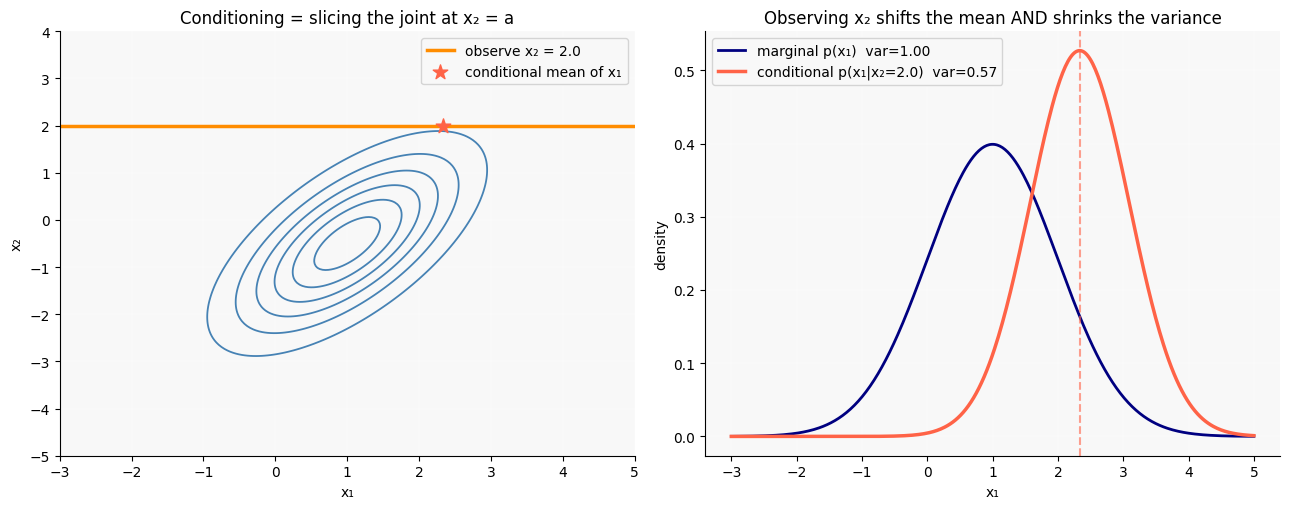

conditional mean = 2.333,  conditional var = 0.573 (was 1.000)


In [10]:
mu = np.array([1.0, -0.5])
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.5]])
a_obs = 2.0                       # we observe x2 = a_obs

# conditional of x1 | x2 = a_obs
m1, m2 = mu
s11, s12, s22 = Sigma[0,0], Sigma[0,1], Sigma[1,1]
mu_c = m1 + s12/s22*(a_obs - m2)
var_c = s11 - s12**2/s22

# contours of the joint
gx = np.linspace(-3, 5, 200); gy = np.linspace(-5, 4, 200)
GX, GY = np.meshgrid(gx, gy)
pos = np.dstack([GX, GY]); Si = inv(Sigma)
diff = pos - mu
Z = np.exp(-0.5*np.einsum('...i,ij,...j->...', diff, Si, diff))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
ax.contour(GX, GY, Z, levels=6, colors=PALETTE[0], linewidths=1.3)
ax.axhline(a_obs, color=PALETTE[3], lw=2.5, label=f"observe x₂ = {a_obs}")
ax.scatter(mu_c, a_obs, color=PALETTE[1], s=120, marker="*", zorder=5,
           label="conditional mean of x₁")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.set_title("Conditioning = slicing the joint at x₂ = a")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
xs = np.linspace(-3, 5, 400)
prior_var = s11
ax.plot(xs, np.exp(-0.5*(xs-m1)**2/prior_var)/np.sqrt(2*np.pi*prior_var),
        color=PALETTE[4], lw=2, label=f"marginal p(x₁)  var={prior_var:.2f}")
ax.plot(xs, np.exp(-0.5*(xs-mu_c)**2/var_c)/np.sqrt(2*np.pi*var_c),
        color=PALETTE[1], lw=2.5, label=f"conditional p(x₁|x₂={a_obs})  var={var_c:.2f}")
ax.axvline(mu_c, color=PALETTE[1], ls="--", alpha=0.6)
ax.set_xlabel("x₁"); ax.set_ylabel("density")
ax.set_title("Observing x₂ shifts the mean AND shrinks the variance")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"conditional mean = {mu_c:.3f},  conditional var = {var_c:.3f} (was {prior_var:.3f})")

### Interactive: drag the observation

Move the slider to change the observed value of $x_2$ and watch the conditional distribution of $x_1$ slide along the
**regression line** $\mu_{1|2} = \mu_1 + \frac{\Sigma_{12}}{\Sigma_{22}}(a-\mu_2)$. Crank up the **correlation** $\rho$ to
see the conditional variance shrink — strong correlation means $x_2$ tells you a lot about $x_1$.

*(If `ipywidgets` isn't installed, the static cell above already tells the story.)*

In [ ]:
try:
    from ipywidgets import interact, FloatSlider

    def show_conditional(a_obs=2.0, rho=0.65):
        mu = np.array([1.0, -0.5])
        sd1, sd2 = 1.0, 1.22
        s12 = rho*sd1*sd2
        Sigma = np.array([[sd1**2, s12],
                          [s12,    sd2**2]])
        m1, m2 = mu
        mu_c = m1 + s12/Sigma[1,1]*(a_obs - m2)
        var_c = Sigma[0,0] - s12**2/Sigma[1,1]

        gx = np.linspace(-3, 5, 160); gy = np.linspace(-5, 4, 160)
        GX, GY = np.meshgrid(gx, gy)
        pos = np.dstack([GX, GY]); Si = inv(Sigma); diff = pos - mu
        Z = np.exp(-0.5*np.einsum('...i,ij,...j->...', diff, Si, diff))

        fig, ax = plt.subplots(figsize=(7.5, 6))
        ax.contour(GX, GY, Z, levels=6, colors=PALETTE[0], linewidths=1.2)
        # regression line of x1 on x2
        a_line = np.linspace(-5, 4, 50)
        ax.plot(m1 + s12/Sigma[1,1]*(a_line - m2), a_line,
                color=PALETTE[2], lw=2, label="regression line  E[x₁|x₂]")
        ax.axhline(a_obs, color=PALETTE[3], lw=2.2, label=f"x₂ = {a_obs:.2f}")
        ax.scatter(mu_c, a_obs, color=PALETTE[1], s=130, marker="*", zorder=5)
        ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        ax.set_title(f"E[x₁|x₂]={mu_c:.2f},  Var[x₁|x₂]={var_c:.2f}  (ρ={rho:.2f})")
        ax.set_xlim(-3,5); ax.set_ylim(-5,4)
        ax.legend(loc="upper left"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    interact(show_conditional,
             a_obs=FloatSlider(min=-4, max=3.5, step=0.25, value=2.0, description="x₂ = a"),
             rho=FloatSlider(min=-0.95, max=0.95, step=0.05, value=0.65, description="ρ"))
except Exception as e:
    print("ipywidgets unavailable — skipping interactive cell.", e)

interactive(children=(FloatSlider(value=2.0, description='x₂ = a', max=3.5, min=-4.0, step=0.25), FloatSlider(…

---
## 7 · Summary

We built a toolbox and used it to derive the single most-asked Gaussian result. Notice how **every row traces back to one
idea — the Schur complement**.

| Concept | Key Idea |
|---|---|
| **Matrix inverse** | The "undo" of a linear map; exists iff $\det\neq 0$ (no information lost / full rank) |
| **2×2 inverse** | $\frac{1}{ad-bc}\begin{psmallmatrix} d & -b \\ -c & a\end{psmallmatrix}$ — memorize it |
| **Schur complement** | $\mathbf{M}/\mathbf{A} = \mathbf{D}-\mathbf{C}\mathbf{A}^{-1}\mathbf{B}$: "block $\mathbf{D}$ minus what $\mathbf{A}$ already explains" |
| **Block determinant** | $\det\mathbf{M} = \det\mathbf{A}\,\det(\mathbf{M}/\mathbf{A})$ — big det → two small ones |
| **Block inverse** | Bottom-right block of $\mathbf{M}^{-1}$ is $(\mathbf{M}/\mathbf{A})^{-1}$ |
| **Woodbury (SMW)** | Invert a low-rank *update* by inverting only the small $k\times k$ core |
| **Sherman–Morrison** | Rank-1 case: denominator is a scalar $1+\mathbf{v}^\top\mathbf{A}^{-1}\mathbf{u}$ — $O(n^2)$ updates |
| **Determinant lemma** | $\det(\mathbf{A}+\mathbf{u}\mathbf{v}^\top)=\det(\mathbf{A})(1+\mathbf{v}^\top\mathbf{A}^{-1}\mathbf{u})$ |
| **MVN density** | $\boldsymbol\mu$ = center, $\mathbf{\Sigma}$ = ellipse shape, $\det\mathbf{\Sigma}$ = volume |
| **Conditional mean** | $\boldsymbol\mu_1 + \mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}(\mathbf{a}-\boldsymbol\mu_2)$ — it's a regression / "beta" |
| **Conditional covariance** | $\mathbf{\Sigma}_{11}-\mathbf{\Sigma}_{12}\mathbf{\Sigma}_{22}^{-1}\mathbf{\Sigma}_{21}$ — the **Schur complement**; doesn't depend on $\mathbf{a}$ |

### Interview cheat-sheet 🎯
- **Invertible** $\iff$ $\det\neq0$ $\iff$ full rank $\iff$ independent columns.
- **Schur complement** = conditional covariance. Say this sentence and you've half-answered the conditional-Gaussian question.
- **Conditioning a Gaussian** gives another Gaussian; mean moves linearly with the observation, variance only shrinks.
- **New data point?** Rank-1 Woodbury / Sherman–Morrison updates the inverse covariance in $O(n^2)$.
- The scalar $1+\mathbf{v}^\top\mathbf{A}^{-1}\mathbf{u}$ links **Sherman–Morrison** and the **determinant lemma** — same Schur identity, two faces.
